# NinaPro DB1 — Focused EDA and Sequence Preparation

## Study scope

This notebook is designed for the following experiment:

```text
Dataset: NinaPro DB1
Subjects: all 27 subjects
Exercise: Exercise 1 only
Movements: 12 active finger movements
Input: sequential 10-channel sEMG
Target: sequential 22-channel glove values
Models to be trained later: LSTM, TCN, and TCN–LSTM
Evaluation: repetition-wise within-subject split
```

## Split used later

```text
Repetitions 1–4  → training
Repetition 5     → validation
Repetitions 6–10 → testing
```

The notebook keeps only useful EDA and prepares temporal sequence indices. It does **not**
create MAV/RMS/WL/VAR tabular features because TCN and LSTM should receive temporal signals.

> The 22 glove columns are raw CyberGlove sensor values. They should not be described as
> calibrated anatomical joint angles.


## 1. Imports and configuration

In [23]:
from pathlib import Path
from collections import Counter
import json
import re
import shutil
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from IPython.display import display
from scipy.io import loadmat

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
FS = 100

# Temporal sequence settings for TCN/LSTM
SEQUENCE_LENGTH = 100       # 100 samples = 1 second at 100 Hz
SEQUENCE_STEP = 10          # 10 samples = 0.1 second hop

# Balanced sample used only for lightweight EDA
EDA_ROWS_PER_FILE = 3000

TRAIN_REPETITIONS = [1, 2, 3, 4]
VALIDATION_REPETITIONS = [5]
TEST_REPETITIONS = [6, 7, 8, 9, 10]

BASE_URL = "https://ninapro.hevs.ch/files/DB1/Preprocessed"

ON_KAGGLE = Path("/kaggle").exists()

WORK_DIR = (
    Path("/kaggle/working/ninapro_db1_e1")
    if ON_KAGGLE
    else Path("./ninapro_db1_e1")
)

ZIP_DIR = WORK_DIR / "zip_files"
MAT_DIR = WORK_DIR / "mat_files"

PREPARED_DIR = (
    Path("/kaggle/working/ninapro_db1_e1_sequences")
    if ON_KAGGLE
    else Path("./ninapro_db1_e1_sequences")
)

ZIP_DIR.mkdir(parents=True, exist_ok=True)
MAT_DIR.mkdir(parents=True, exist_ok=True)
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RANDOM_STATE)

print("Working directory:", WORK_DIR.resolve())
print("Prepared directory:", PREPARED_DIR.resolve())


Working directory: /kaggle/working/ninapro_db1_e1
Prepared directory: /kaggle/working/ninapro_db1_e1_sequences


## 2. Locate or download the dataset

The code first searches Kaggle input for Exercise 1 MATLAB files. If they are not available,
it downloads the official preprocessed subject ZIP files.


In [24]:
def natural_key(path):
    name = Path(path).name

    subject_match = re.search(r"[Ss](\d+)", name)
    exercise_match = re.search(r"[Ee](\d+)", name)

    return (
        int(subject_match.group(1)) if subject_match else 10**9,
        int(exercise_match.group(1)) if exercise_match else 10**9,
        name,
    )


def parse_file_ids(file_path):
    name = Path(file_path).stem

    def get_id(letter):
        match = re.search(
            fr"[{letter.upper()}{letter.lower()}](\d+)",
            name,
        )
        return int(match.group(1)) if match else None

    return {
        "subject": get_id("S"),
        "exercise": get_id("E"),
        "acquisition": get_id("A"),
    }


def find_mat_files(root):
    if not root.exists():
        return []

    files = []

    for path in root.rglob("*.mat"):
        ids = parse_file_ids(path)

        if (
            ids["subject"] is not None
            and ids["exercise"] == 1
        ):
            files.append(path)

    return sorted(files, key=natural_key)


# Search Kaggle input first
mat_files = []

if ON_KAGGLE:
    mat_files = find_mat_files(
        Path("/kaggle/input")
    )

# Search local extracted directory
if not mat_files:
    mat_files = find_mat_files(
        MAT_DIR
    )

# Download only when files are unavailable
if len(mat_files) < 27:
    print(
        "Complete Exercise 1 files were not found. "
        "Downloading official preprocessed DB1 files..."
    )

    for subject in range(1, 28):
        zip_path = ZIP_DIR / f"s{subject}.zip"
        subject_dir = MAT_DIR / f"s{subject}"

        existing = find_mat_files(
            subject_dir
        )

        if existing:
            print(
                f"[{subject:02d}/27] already available"
            )
            continue

        if not (
            zip_path.exists()
            and zipfile.is_zipfile(zip_path)
        ):
            zip_path.unlink(
                missing_ok=True
            )

            response = requests.get(
                f"{BASE_URL}/s{subject}.zip",
                stream=True,
                timeout=300,
                headers={
                    "User-Agent": "Mozilla/5.0"
                },
            )

            response.raise_for_status()

            with open(
                zip_path,
                "wb",
            ) as file:
                for chunk in response.iter_content(
                    1024 * 1024
                ):
                    if chunk:
                        file.write(chunk)

            if not zipfile.is_zipfile(
                zip_path
            ):
                zip_path.unlink(
                    missing_ok=True
                )

                raise RuntimeError(
                    f"Subject {subject} ZIP is invalid."
                )

        subject_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        with zipfile.ZipFile(
            zip_path
        ) as archive:
            archive.extractall(
                subject_dir
            )

        print(
            f"[{subject:02d}/27] extracted"
        )

    mat_files = find_mat_files(
        MAT_DIR
    )

print("\nExercise 1 MATLAB files:", len(mat_files))
print("Expected:", 27)

if len(mat_files) != 27:
    raise RuntimeError(
        "Expected exactly 27 Exercise 1 files. "
        "Check the dataset path and filenames."
    )



Exercise 1 MATLAB files: 27
Expected: 27


## 3. Loading and utility functions

In [25]:
def load_db1(file_path):
    raw = loadmat(
        file_path,
        squeeze_me=True,
        struct_as_record=False,
    )

    def matrix(name):
        if name not in raw:
            return None

        return np.asarray(
            raw[name]
        )

    def vector(name):
        value = matrix(name)

        if value is None:
            return None

        return np.asarray(
            value
        ).reshape(-1)

    return {
        "emg": matrix("emg"),
        "glove": matrix("glove"),
        "restimulus": vector(
            "restimulus"
        ),
        "rerepetition": vector(
            "rerepetition"
        ),
    }


def contiguous_runs(indices):
    indices = np.asarray(
        indices,
        dtype=np.int64,
    )

    if len(indices) == 0:
        return []

    split_points = (
        np.where(
            np.diff(indices) > 1
        )[0]
        + 1
    )

    return np.split(
        indices,
        split_points,
    )


def describe_channels(
    dataframe,
    columns,
):
    values = dataframe[columns]

    return pd.DataFrame({
        "mean": values.mean(),
        "median": values.median(),
        "std": values.std(),
        "min": values.min(),
        "max": values.max(),
        "skewness": values.skew(),
    })


# A. Exercise 1 dataset structure and quality


## A1. Variables in one Exercise 1 file

In [26]:
sample_path = mat_files[0]

sample_raw = loadmat(
    sample_path,
    squeeze_me=True,
    struct_as_record=False,
)

sample_variables = []

for variable_name, value in sample_raw.items():
    if variable_name.startswith("__"):
        continue

    array = np.asarray(value)

    sample_variables.append({
        "Variable": variable_name,
        "Shape": str(array.shape),
        "Data_type": str(array.dtype),
    })

display(
    pd.DataFrame(
        sample_variables
    )
)

print("Sample file:", sample_path.name)


,Variable,Shape,Data_type
0,emg,"(101014, 10)",float64
1,stimulus,"(101014,)",uint8
2,glove,"(101014, 22)",float64
3,subject,(),int64
4,exercise,(),int64
5,repetition,"(101014,)",uint8
6,restimulus,"(101014,)",uint8
7,rerepetition,"(101014,)",uint8


Sample file: S1_A1_E1.mat


## A2. Full Exercise 1 quality audit

The audit checks all 27 Exercise 1 files for:

- synchronized EMG, glove, movement, and repetition lengths;
- missing and infinite signal values;
- expected 10 EMG and 22 glove channels;
- movement and repetition coverage.


In [27]:
inventory_rows = []
movement_sample_counts = Counter()
repetition_counts = Counter()

for position, file_path in enumerate(
    mat_files,
    start=1,
):
    data = load_db1(
        file_path
    )

    ids = parse_file_ids(
        file_path
    )

    emg = np.asarray(
        data["emg"]
    )

    glove = np.asarray(
        data["glove"]
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data["rerepetition"],
        dtype=np.int16,
    )

    lengths = [
        len(emg),
        len(glove),
        len(labels),
        len(repetitions),
    ]

    aligned = len(
        set(lengths)
    ) == 1

    signal_values = np.column_stack([
        emg,
        glove,
    ])

    for movement_label, count in zip(
        *np.unique(
            labels,
            return_counts=True,
        )
    ):
        movement_sample_counts[
            int(movement_label)
        ] += int(count)

    active_pairs = pd.DataFrame({
        "movement": labels,
        "repetition": repetitions,
    })

    active_pairs = active_pairs.loc[
        active_pairs["movement"] > 0
    ].drop_duplicates()

    for row in active_pairs.itertuples(
        index=False
    ):
        repetition_counts[
            (
                int(ids["subject"]),
                int(row.movement),
                int(row.repetition),
            )
        ] += 1

    active_mask = labels > 0

    inventory_rows.append({
        "File": file_path.name,
        "Subject": int(
            ids["subject"]
        ),
        "Samples": len(emg),
        "Duration_min": (
            len(emg)
            / FS
            / 60
        ),
        "EMG_shape": str(
            emg.shape
        ),
        "Glove_shape": str(
            glove.shape
        ),
        "Aligned": aligned,
        "Missing_values": int(
            np.isnan(
                signal_values
            ).sum()
        ),
        "Infinite_values": int(
            np.isinf(
                signal_values
            ).sum()
        ),
        "Movement_EMG_RMS": float(
            np.sqrt(
                np.mean(
                    emg[
                        active_mask
                    ] ** 2
                )
            )
        ),
        "Movement_glove_range": float(
            np.ptp(
                glove[
                    active_mask
                ],
                axis=0,
            ).mean()
        ),
    })

    if (
        position % 5 == 0
        or position == len(mat_files)
    ):
        print(
            f"Audited {position}/{len(mat_files)} files"
        )


inventory_df = (
    pd.DataFrame(
        inventory_rows
    )
    .sort_values("Subject")
    .reset_index(drop=True)
)

display(
    inventory_df.head()
)

assert inventory_df["Subject"].nunique() == 27
assert inventory_df["Aligned"].all()
assert inventory_df["Missing_values"].sum() == 0
assert inventory_df["Infinite_values"].sum() == 0

print("\nQuality audit passed.")


Audited 5/27 files
Audited 10/27 files
Audited 15/27 files
Audited 20/27 files
Audited 25/27 files
Audited 27/27 files


,File,Subject,Samples,Duration_min,EMG_shape,Glove_shape,Aligned,Missing_values,Infinite_values,Movement_EMG_RMS,Movement_glove_range
0,S1_A1_E1.mat,1,101014,16.835667,"(101014, 10)","(101014, 22)",True,0,0,0.311446,99.175826
1,S2_A1_E1.mat,2,100686,16.781000,"(100686, 10)","(100686, 22)",True,0,0,0.508929,99.173695
2,S3_A1_E1.mat,3,100720,16.786667,"(100720, 10)","(100720, 22)",True,0,0,0.357098,93.136364
3,S4_A1_E1.mat,4,100835,16.805833,"(100835, 10)","(100835, 22)",True,0,0,0.223463,77.355087
4,S5_A1_E1.mat,5,100894,16.815667,"(100894, 10)","(100894, 22)",True,0,0,0.552701,107.823809



Quality audit passed.


## A3. Compact Exercise 1 summary

In [28]:
summary_df = pd.DataFrame({
    "Item": [
        "Dataset",
        "Selected exercise",
        "Subjects",
        "MATLAB files",
        "Total samples",
        "Total duration",
        "EMG channels",
        "Glove channels",
        "Active movements",
        "Repetitions per movement",
        "Sampling frequency",
        "Aligned files",
        "Missing values",
        "Infinite values",
    ],
    "Result": [
        "NinaPro DB1",
        "Exercise 1",
        inventory_df["Subject"].nunique(),
        len(inventory_df),
        f"{inventory_df['Samples'].sum():,}",
        f"{inventory_df['Duration_min'].sum():.2f} minutes",
        10,
        22,
        12,
        10,
        f"{FS} Hz",
        f"{inventory_df['Aligned'].sum()}/{len(inventory_df)}",
        int(
            inventory_df[
                "Missing_values"
            ].sum()
        ),
        int(
            inventory_df[
                "Infinite_values"
            ].sum()
        ),
    ],
})

display(summary_df)


,Item,Result
0,Dataset,NinaPro DB1
1,Selected exercise,Exercise 1
2,Subjects,27
3,MATLAB files,27
4,Total samples,"2,731,393"
5,Total duration,455.23 minutes
6,EMG channels,10
7,Glove channels,22
8,Active movements,12
9,Repetitions per movement,10


# B. Movement and repetition coverage


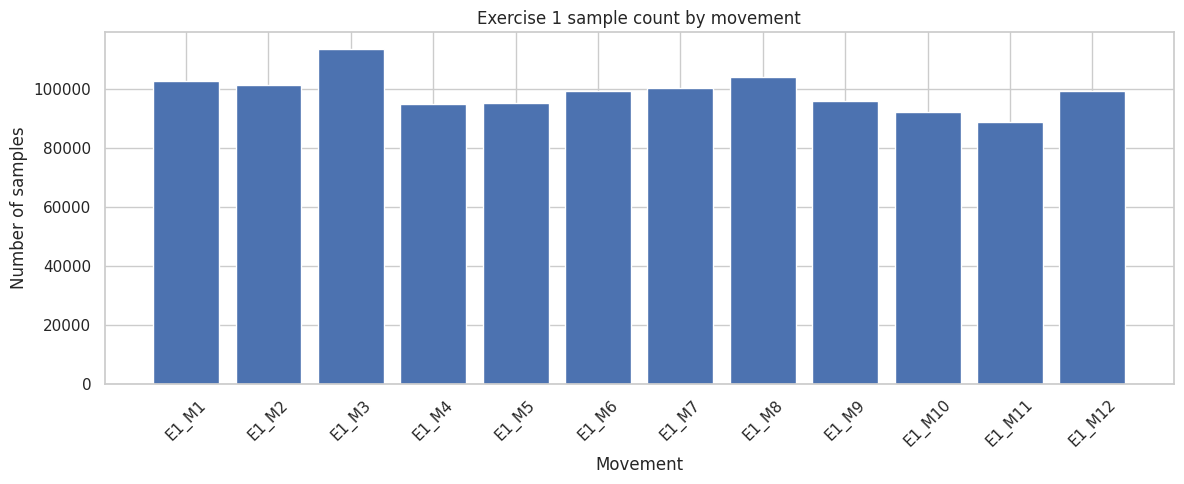

Subject–movement pairs with all 10 repetitions: 324/324


,Subject,Movement,Repetitions_present,Complete_10_repetitions


In [29]:
movement_rows = []

for movement_label in range(
    1,
    13,
):
    movement_rows.append({
        "Movement": f"E1_M{movement_label}",
        "Samples": movement_sample_counts[
            movement_label
        ],
    })

movement_df = pd.DataFrame(
    movement_rows
)

plt.figure(
    figsize=(12, 5)
)

plt.bar(
    movement_df["Movement"],
    movement_df["Samples"],
)

plt.title(
    "Exercise 1 sample count by movement"
)

plt.xlabel(
    "Movement"
)

plt.ylabel(
    "Number of samples"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

coverage_rows = []

for subject in range(
    1,
    28,
):
    for movement in range(
        1,
        13,
    ):
        present_repetitions = [
            repetition
            for repetition in range(
                1,
                11,
            )
            if repetition_counts[
                (
                    subject,
                    movement,
                    repetition,
                )
            ] > 0
        ]

        coverage_rows.append({
            "Subject": subject,
            "Movement": movement,
            "Repetitions_present": len(
                present_repetitions
            ),
            "Complete_10_repetitions": (
                len(
                    present_repetitions
                )
                == 10
            ),
        })

coverage_df = pd.DataFrame(
    coverage_rows
)

print(
    "Subject–movement pairs with all 10 repetitions:",
    f"{coverage_df['Complete_10_repetitions'].sum()}/{len(coverage_df)}",
)

display(
    coverage_df[
        ~coverage_df[
            "Complete_10_repetitions"
        ]
    ].head(20)
)


# C. Balanced signal sample for descriptive EDA

A balanced number of rows is sampled from each Exercise 1 file. This keeps the plots fast while
all integrity and coverage checks above still use every sample.


In [30]:
sampled_parts = []

for file_index, file_path in enumerate(
    mat_files
):
    data = load_db1(
        file_path
    )

    subject = parse_file_ids(
        file_path
    )["subject"]

    row_count = len(
        data["emg"]
    )

    local_rng = np.random.default_rng(
        RANDOM_STATE
        + file_index
    )

    selected_rows = np.sort(
        local_rng.choice(
            row_count,
            size=min(
                EDA_ROWS_PER_FILE,
                row_count,
            ),
            replace=False,
        )
    )

    part = pd.DataFrame(
        np.column_stack([
            data["emg"][
                selected_rows
            ],
            data["glove"][
                selected_rows
            ],
        ]),
        columns=(
            [
                f"EMG_{channel + 1}"
                for channel in range(10)
            ]
            + [
                f"GLOVE_{channel + 1}"
                for channel in range(22)
            ]
        ),
    )

    labels = data[
        "restimulus"
    ][selected_rows].astype(
        np.int16
    )

    part["Subject"] = int(
        subject
    )

    part["Movement"] = labels

    part["Activity"] = np.where(
        labels > 0,
        "Movement",
        "Rest",
    )

    part["Repetition"] = data[
        "rerepetition"
    ][selected_rows].astype(
        np.int16
    )

    sampled_parts.append(
        part
    )


eda_df = pd.concat(
    sampled_parts,
    ignore_index=True,
)

emg_columns = [
    f"EMG_{channel + 1}"
    for channel in range(10)
]

glove_columns = [
    f"GLOVE_{channel + 1}"
    for channel in range(22)
]

eda_df["EMG_RMS"] = np.sqrt(
    np.mean(
        eda_df[
            emg_columns
        ].to_numpy() ** 2,
        axis=1,
    )
)

print(
    "Balanced EDA table:",
    eda_df.shape,
)

print(
    "Rows per subject:",
    eda_df.groupby(
        "Subject"
    ).size().unique(),
)


Balanced EDA table: (81000, 37)
Rows per subject: [3000]


## C1. Descriptive statistics and channel quality


In [31]:
emg_statistics = describe_channels(
    eda_df,
    emg_columns,
)

glove_statistics = describe_channels(
    eda_df,
    glove_columns,
)

print("EMG descriptive statistics")
display(
    emg_statistics.round(4)
)

print("Glove descriptive statistics")
display(
    glove_statistics.round(3)
)

channel_quality = pd.DataFrame({
    "Channel": (
        emg_columns
        + glove_columns
    ),
    "Standard_deviation": [
        eda_df[column].std()
        for column in (
            emg_columns
            + glove_columns
        )
    ],
})

channel_quality[
    "Near_constant"
] = (
    channel_quality[
        "Standard_deviation"
    ]
    < 1e-6
)

print("Near-constant channels:")
display(
    channel_quality.loc[
        channel_quality[
            "Near_constant"
        ]
    ]
)

if not channel_quality[
    "Near_constant"
].any():
    print("None detected.")


EMG descriptive statistics


,mean,median,std,min,max,skewness
EMG_1,0.1942,0.0537,0.3244,0.0024,4.6411,3.5101
EMG_2,0.1230,0.0073,0.2286,0.0000,3.3838,3.1560
EMG_3,0.1224,0.0049,0.3096,0.0024,4.6606,6.4893
EMG_4,0.0421,0.0024,0.1265,0.0000,4.6631,10.7384
EMG_5,0.0119,0.0024,0.0337,0.0024,0.9473,7.0871
EMG_6,0.0344,0.0024,0.0922,0.0000,2.1704,6.5621
EMG_7,0.3034,0.1270,0.5314,0.0024,4.6655,4.3058
EMG_8,0.3027,0.1929,0.3716,0.0024,4.6655,3.3365
EMG_9,0.1175,0.0049,0.2951,0.0000,4.6631,6.1023
EMG_10,0.2343,0.1172,0.3497,0.0000,4.6313,3.5214


Glove descriptive statistics


,mean,median,std,min,max,skewness
GLOVE_1,123.406,122.000,22.354,35.000,255.000,0.739
GLOVE_2,113.830,113.000,15.597,1.000,218.000,0.347
GLOVE_3,111.040,112.000,12.198,12.000,185.000,-0.557
GLOVE_4,136.740,135.000,13.871,94.000,187.000,0.278
GLOVE_5,115.469,116.000,18.053,29.607,198.000,-0.431
GLOVE_6,74.209,69.000,26.201,2.944,203.000,1.596
GLOVE_7,76.828,77.000,11.710,42.000,174.000,1.536
GLOVE_8,104.047,104.000,17.267,15.716,173.000,-0.209
GLOVE_9,83.359,81.000,24.549,29.000,200.000,1.150
GLOVE_10,72.368,72.000,9.324,15.052,123.000,0.200


Near-constant channels:


,Channel,Standard_deviation,Near_constant


None detected.


## C2. Representative distributions


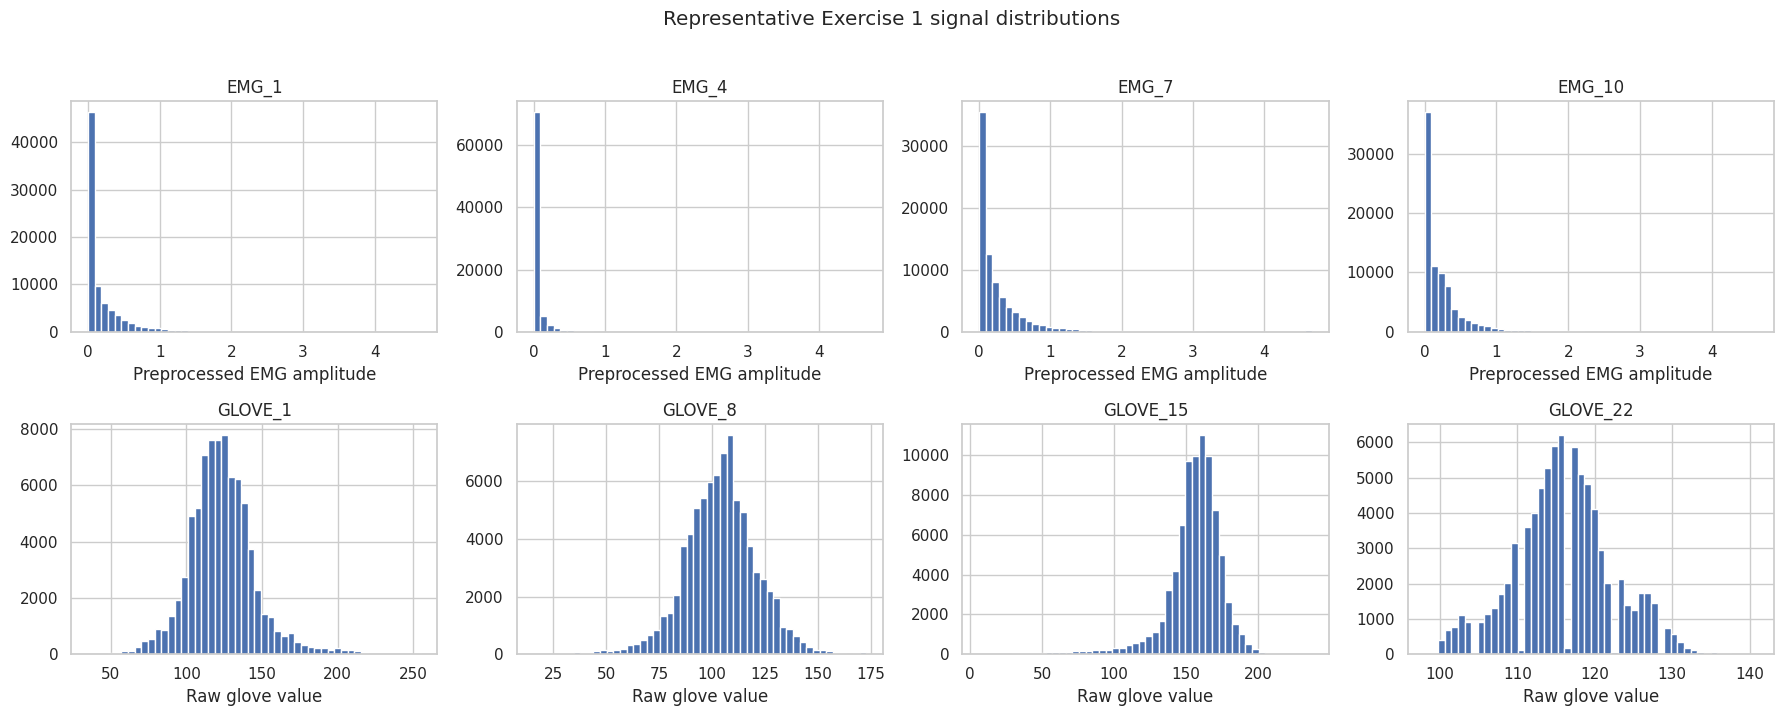

In [32]:
selected_emg = [
    "EMG_1",
    "EMG_4",
    "EMG_7",
    "EMG_10",
]

selected_glove = [
    "GLOVE_1",
    "GLOVE_8",
    "GLOVE_15",
    "GLOVE_22",
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 7),
)

for axis, column in zip(
    axes[0],
    selected_emg,
):
    axis.hist(
        eda_df[column],
        bins=50,
    )

    axis.set_title(
        column
    )

    axis.set_xlabel(
        "Preprocessed EMG amplitude"
    )

for axis, column in zip(
    axes[1],
    selected_glove,
):
    axis.hist(
        eda_df[column],
        bins=50,
    )

    axis.set_title(
        column
    )

    axis.set_xlabel(
        "Raw glove value"
    )

fig.suptitle(
    "Representative Exercise 1 signal distributions",
    y=1.02,
)

plt.tight_layout()
plt.show()


## C3. Rest versus movement EMG


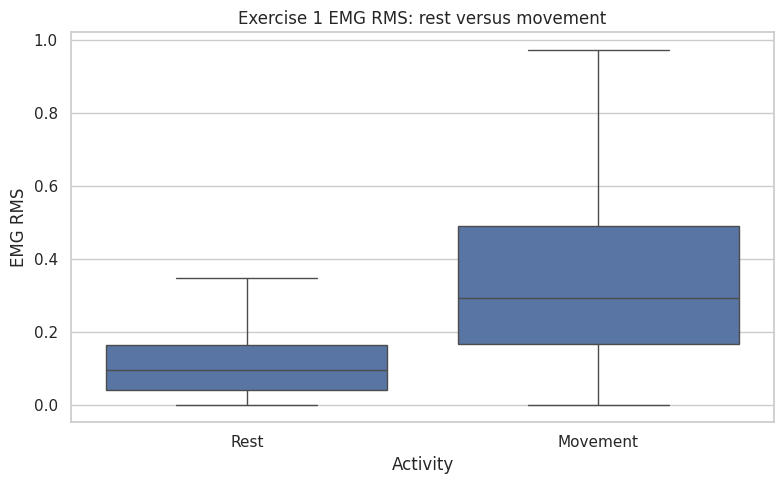

,mean,median,std
Activity,,,
Movement,0.3849,0.2939,0.3219
Rest,0.1168,0.0971,0.0976


In [33]:
plot_sample = eda_df.sample(
    min(
        50_000,
        len(eda_df),
    ),
    random_state=RANDOM_STATE,
)

plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=plot_sample,
    x="Activity",
    y="EMG_RMS",
    order=[
        "Rest",
        "Movement",
    ],
    showfliers=False,
)

plt.title(
    "Exercise 1 EMG RMS: rest versus movement"
)

plt.xlabel(
    "Activity"
)

plt.ylabel(
    "EMG RMS"
)

plt.tight_layout()
plt.show()

display(
    eda_df.groupby(
        "Activity"
    )["EMG_RMS"]
    .agg([
        "mean",
        "median",
        "std",
    ])
    .round(4)
)


# D. Temporal behaviour


## D1. Synchronized EMG, glove, and movement labels


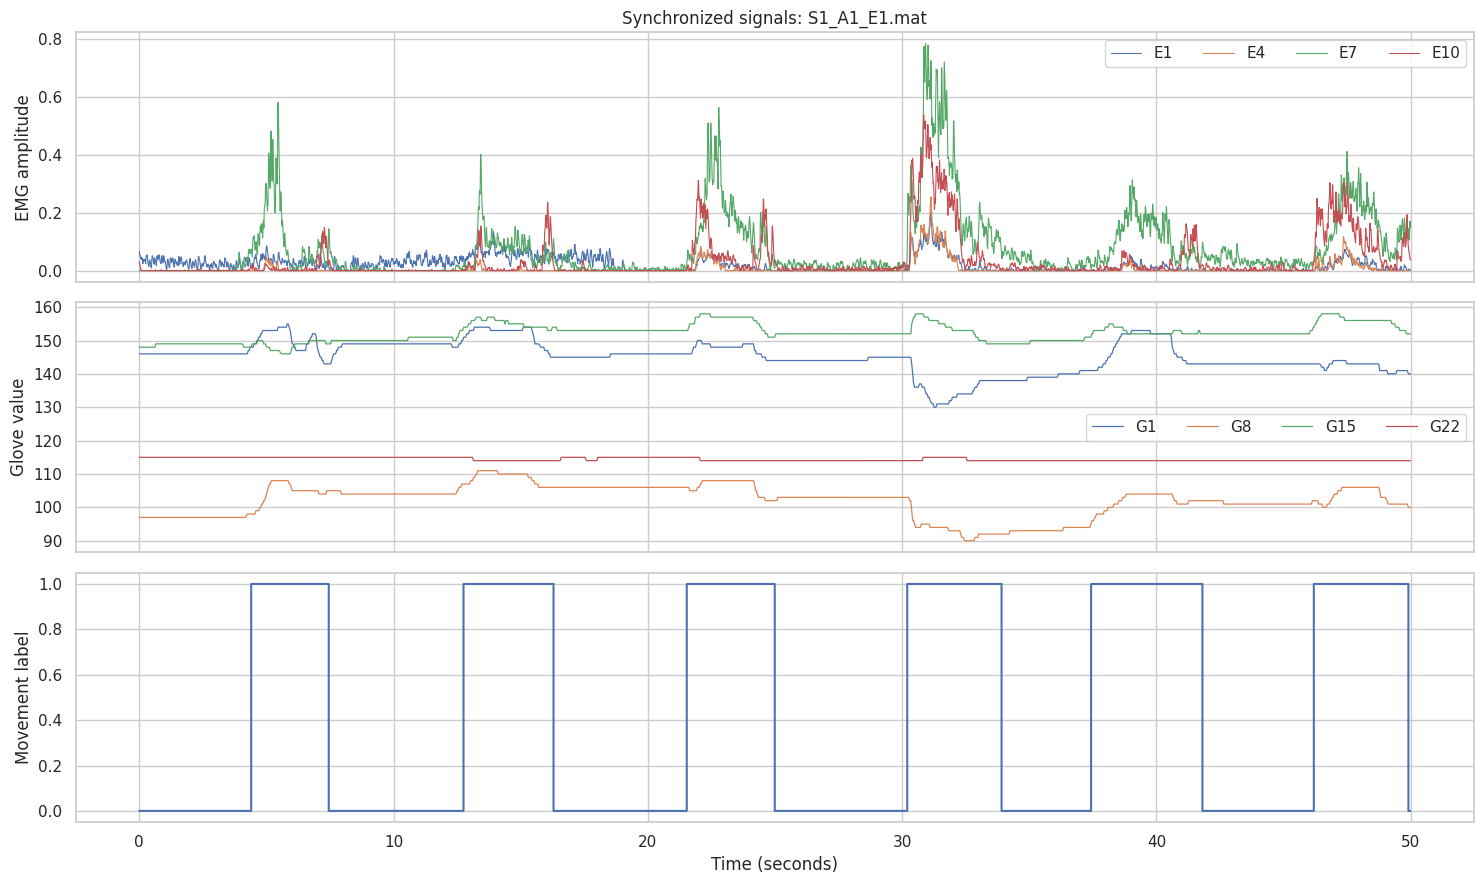

In [34]:
example_path = mat_files[0]
example = load_db1(
    example_path
)

show_seconds = 50

stop = min(
    len(
        example["emg"]
    ),
    show_seconds * FS,
)

time_axis = np.arange(
    stop
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 9),
    sharex=True,
)

for channel in [
    0,
    3,
    6,
    9,
]:
    axes[0].plot(
        time_axis,
        example["emg"][
            :stop,
            channel,
        ],
        linewidth=0.8,
        label=f"E{channel + 1}",
    )

axes[0].set_title(
    f"Synchronized signals: {example_path.name}"
)

axes[0].set_ylabel(
    "EMG amplitude"
)

axes[0].legend(
    ncol=4
)

for channel in [
    0,
    7,
    14,
    21,
]:
    axes[1].plot(
        time_axis,
        example["glove"][
            :stop,
            channel,
        ],
        linewidth=0.9,
        label=f"G{channel + 1}",
    )

axes[1].set_ylabel(
    "Glove value"
)

axes[1].legend(
    ncol=4
)

axes[2].step(
    time_axis,
    example["restimulus"][
        :stop
    ],
    where="post",
)

axes[2].set_ylabel(
    "Movement label"
)

axes[2].set_xlabel(
    "Time (seconds)"
)

plt.tight_layout()
plt.show()


## D2. Repetition consistency for one movement


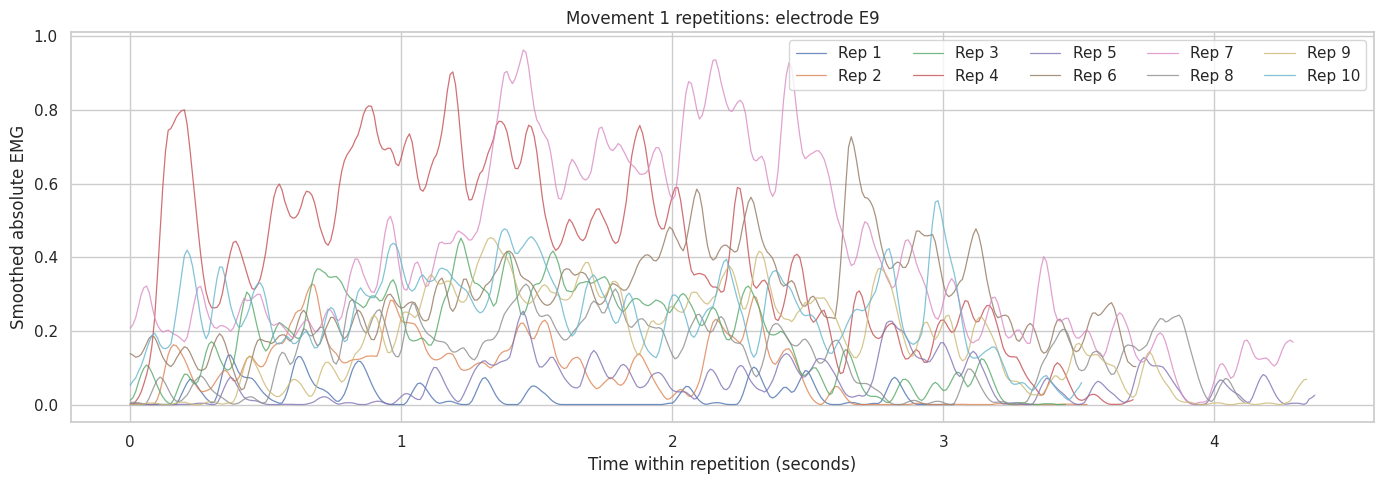

,Repetition,Duration_seconds,Mean_absolute_EMG
0,1,3.05,0.0288
1,2,3.54,0.0954
2,3,3.46,0.1896
3,4,3.71,0.3986
4,5,4.38,0.0590
5,6,3.72,0.2974
6,7,4.30,0.3982
7,8,4.12,0.1343
8,9,4.35,0.1691
9,10,3.52,0.2545


In [35]:
example_labels = example[
    "restimulus"
].astype(
    np.int16
)

example_repetitions = example[
    "rerepetition"
].astype(
    np.int16
)

example_emg = np.asarray(
    example["emg"]
)

selected_movement = 1

movement_mask = (
    example_labels
    == selected_movement
)

selected_electrode = int(
    np.argmax(
        np.sqrt(
            np.mean(
                example_emg[
                    movement_mask
                ] ** 2,
                axis=0,
            )
        )
    )
)

plt.figure(
    figsize=(14, 5)
)

repetition_rows = []

for repetition in range(
    1,
    11,
):
    indices = np.flatnonzero(
        (
            example_labels
            == selected_movement
        )
        & (
            example_repetitions
            == repetition
        )
    )

    runs = contiguous_runs(
        indices
    )

    if not runs:
        continue

    segment = max(
        runs,
        key=len,
    )

    signal = np.abs(
        example_emg[
            segment,
            selected_electrode,
        ]
    )

    signal = (
        pd.Series(signal)
        .rolling(
            5,
            center=True,
            min_periods=1,
        )
        .mean()
        .to_numpy()
    )

    local_time = np.arange(
        len(signal)
    ) / FS

    plt.plot(
        local_time,
        signal,
        linewidth=0.9,
        alpha=0.8,
        label=f"Rep {repetition}",
    )

    repetition_rows.append({
        "Repetition": repetition,
        "Duration_seconds": (
            len(signal)
            / FS
        ),
        "Mean_absolute_EMG": float(
            signal.mean()
        ),
    })

plt.title(
    f"Movement 1 repetitions: electrode E{selected_electrode + 1}"
)

plt.xlabel(
    "Time within repetition (seconds)"
)

plt.ylabel(
    "Smoothed absolute EMG"
)

plt.legend(
    ncol=5
)

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        repetition_rows
    ).round(4)
)


# E. Between-subject variability


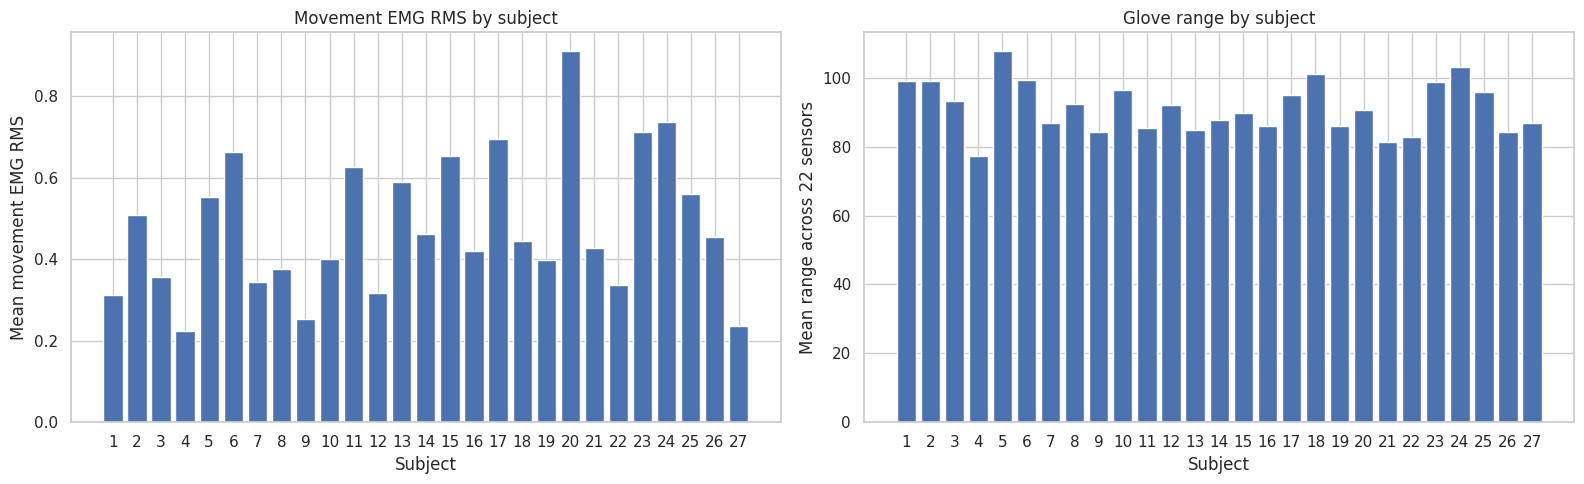

Between-subject EMG RMS coefficient of variation: 36.1%
Between-subject glove-range coefficient of variation: 8.2%


In [36]:
subject_variability = inventory_df[[
    "Subject",
    "Movement_EMG_RMS",
    "Movement_glove_range",
]].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
)

axes[0].bar(
    subject_variability[
        "Subject"
    ].astype(str),
    subject_variability[
        "Movement_EMG_RMS"
    ],
)

axes[0].set_title(
    "Movement EMG RMS by subject"
)

axes[0].set_xlabel(
    "Subject"
)

axes[0].set_ylabel(
    "Mean movement EMG RMS"
)

axes[1].bar(
    subject_variability[
        "Subject"
    ].astype(str),
    subject_variability[
        "Movement_glove_range"
    ],
)

axes[1].set_title(
    "Glove range by subject"
)

axes[1].set_xlabel(
    "Subject"
)

axes[1].set_ylabel(
    "Mean range across 22 sensors"
)

plt.tight_layout()
plt.show()

emg_cv = (
    100
    * subject_variability[
        "Movement_EMG_RMS"
    ].std()
    / subject_variability[
        "Movement_EMG_RMS"
    ].mean()
)

glove_cv = (
    100
    * subject_variability[
        "Movement_glove_range"
    ].std()
    / subject_variability[
        "Movement_glove_range"
    ].mean()
)

print(
    f"Between-subject EMG RMS coefficient of variation: {emg_cv:.1f}%"
)

print(
    f"Between-subject glove-range coefficient of variation: {glove_cv:.1f}%"
)


# F. Simple EMG–glove relationship check

This heatmap is descriptive only. It does not replace a temporal regression model.


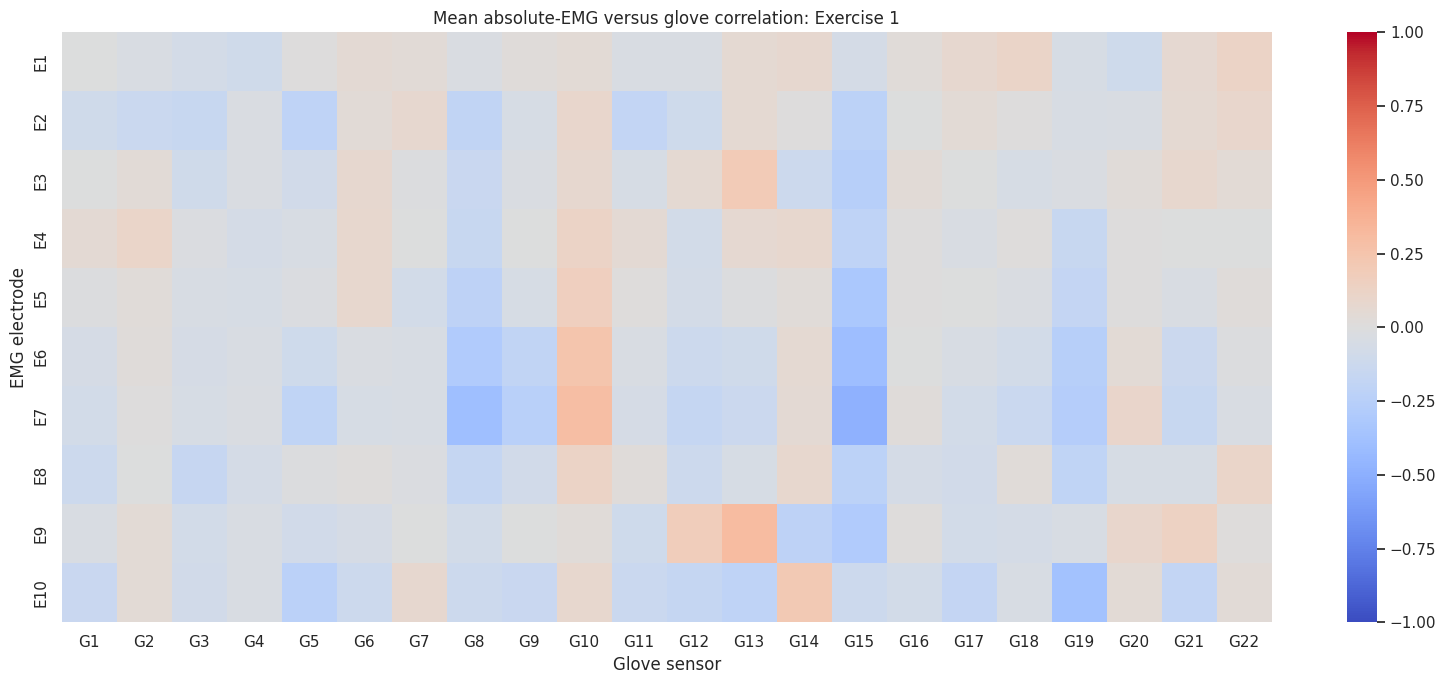

Maximum absolute correlation: 0.487


In [37]:
correlation_blocks = []

for file_path in mat_files:
    data = load_db1(
        file_path
    )

    labels = data[
        "restimulus"
    ].astype(
        np.int16
    )

    active = labels > 0

    emg_absolute = np.abs(
        np.asarray(
            data["emg"]
        )[active]
    )

    glove = np.asarray(
        data["glove"]
    )[active]

    combined = np.column_stack([
        emg_absolute,
        glove,
    ])

    correlation = np.corrcoef(
        combined.T
    )[
        :10,
        10:,
    ]

    correlation_blocks.append(
        correlation
    )


mean_emg_glove_correlation = np.nanmean(
    correlation_blocks,
    axis=0,
)

plt.figure(
    figsize=(16, 7)
)

sns.heatmap(
    mean_emg_glove_correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    xticklabels=[
        f"G{channel + 1}"
        for channel in range(22)
    ],
    yticklabels=[
        f"E{channel + 1}"
        for channel in range(10)
    ],
)

plt.title(
    "Mean absolute-EMG versus glove correlation: Exercise 1"
)

plt.xlabel(
    "Glove sensor"
)

plt.ylabel(
    "EMG electrode"
)

plt.tight_layout()
plt.show()

print(
    "Maximum absolute correlation:",
    round(
        float(
            np.nanmax(
                np.abs(
                    mean_emg_glove_correlation
                )
            )
        ),
        3,
    ),
)


# G. Prepare temporal data for TCN and LSTM

## Why no 40-feature table is created

The previous notebook converted every 200 ms window into MAV, RMS, waveform length, and
variance. That is useful for Random Forest or MLP, but it removes much of the temporal structure
needed by TCN and LSTM.

This notebook saves:

```text
continuous EMG array       → (total samples, 10)
continuous glove array     → (total samples, 22)
sequence-index table       → identifies valid 100-sample sequences
```

Each sequence stays inside one subject, one movement, and one repetition. The large 3-D sequence
arrays are not materialized, which saves several gigabytes of storage.


## G1. Build continuous arrays and leakage-safe sequence index


In [38]:
emg_parts = []
glove_parts = []
label_parts = []
repetition_parts = []

manifest_rows = []
sequence_rows = []

global_offset = 0

for file_index, file_path in enumerate(
    mat_files
):
    data = load_db1(
        file_path
    )

    subject = int(
        parse_file_ids(
            file_path
        )["subject"]
    )

    emg = np.asarray(
        data["emg"],
        dtype=np.float32,
    )

    glove = np.asarray(
        data["glove"],
        dtype=np.float32,
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data["rerepetition"],
        dtype=np.int16,
    )

    file_start = global_offset
    file_stop = (
        file_start
        + len(emg)
    )

    manifest_rows.append({
        "file_index": file_index,
        "file": file_path.name,
        "subject": subject,
        "global_start": file_start,
        "global_stop": file_stop,
        "samples": len(emg),
    })

    # Build sequences only from active movements.
    for movement in range(
        1,
        13,
    ):
        for repetition in range(
            1,
            11,
        ):
            indices = np.flatnonzero(
                (
                    labels
                    == movement
                )
                & (
                    repetitions
                    == repetition
                )
            )

            for run in contiguous_runs(
                indices
            ):
                if len(run) < SEQUENCE_LENGTH:
                    continue

                run_start = int(
                    run[0]
                )

                run_stop = int(
                    run[-1]
                    + 1
                )

                for local_start in range(
                    run_start,
                    run_stop
                    - SEQUENCE_LENGTH
                    + 1,
                    SEQUENCE_STEP,
                ):
                    global_start = (
                        file_start
                        + local_start
                    )

                    sequence_rows.append({
                        "subject": subject,
                        "movement": movement,
                        "repetition": repetition,
                        "file_index": file_index,
                        "local_start": local_start,
                        "global_start": global_start,
                        "global_stop": (
                            global_start
                            + SEQUENCE_LENGTH
                        ),
                        "split": (
                            "train"
                            if repetition
                            in TRAIN_REPETITIONS
                            else (
                                "validation"
                                if repetition
                                in VALIDATION_REPETITIONS
                                else "test"
                            )
                        ),
                    })

    emg_parts.append(
        emg
    )

    glove_parts.append(
        glove
    )

    label_parts.append(
        labels
    )

    repetition_parts.append(
        repetitions
    )

    global_offset = file_stop

    if (
        file_index + 1
    ) % 5 == 0 or (
        file_index + 1
        == len(mat_files)
    ):
        print(
            f"Prepared {file_index + 1}/{len(mat_files)} files"
        )


all_emg = np.concatenate(
    emg_parts,
    axis=0,
).astype(np.float32)

all_glove = np.concatenate(
    glove_parts,
    axis=0,
).astype(np.float32)

all_labels = np.concatenate(
    label_parts,
    axis=0,
).astype(np.int16)

all_repetitions = np.concatenate(
    repetition_parts,
    axis=0,
).astype(np.int16)

file_manifest = pd.DataFrame(
    manifest_rows
)

sequence_index = pd.DataFrame(
    sequence_rows
)

print("Continuous EMG:", all_emg.shape)
print("Continuous glove:", all_glove.shape)
print("Sequence index:", sequence_index.shape)

display(
    sequence_index.groupby(
        "split"
    ).size().rename(
        "sequences"
    ).to_frame()
)

assert (
    sequence_index[
        "global_stop"
    ].max()
    <= len(all_emg)
)

assert set(
    sequence_index.loc[
        sequence_index[
            "split"
        ]
        == "train",
        "repetition",
    ].unique()
) == set(
    TRAIN_REPETITIONS
)

assert set(
    sequence_index.loc[
        sequence_index[
            "split"
        ]
        == "validation",
        "repetition",
    ].unique()
) == set(
    VALIDATION_REPETITIONS
)

assert set(
    sequence_index.loc[
        sequence_index[
            "split"
        ]
        == "test",
        "repetition",
    ].unique()
) == set(
    TEST_REPETITIONS
)

print("Sequence and split checks passed.")


Prepared 5/27 files
Prepared 10/27 files
Prepared 15/27 files
Prepared 20/27 files
Prepared 25/27 files
Prepared 27/27 files
Continuous EMG: (2731393, 10)
Continuous glove: (2731393, 22)
Sequence index: (88312, 8)


,sequences
split,
test,43552
train,35994
validation,8766


Sequence and split checks passed.


## G2. Verify one temporal sequence


In [39]:
example_sequence = sequence_index.iloc[
    0
]

start = int(
    example_sequence[
        "global_start"
    ]
)

stop = int(
    example_sequence[
        "global_stop"
    ]
)

X_example = all_emg[
    start:stop
]

Y_example = all_glove[
    start:stop
]

print(
    "Example input shape:",
    X_example.shape,
)

print(
    "Example target shape:",
    Y_example.shape,
)

print(
    "Subject:",
    int(
        example_sequence[
            "subject"
        ]
    ),
)

print(
    "Movement:",
    int(
        example_sequence[
            "movement"
        ]
    ),
)

print(
    "Repetition:",
    int(
        example_sequence[
            "repetition"
        ]
    ),
)

assert X_example.shape == (
    SEQUENCE_LENGTH,
    10,
)

assert Y_example.shape == (
    SEQUENCE_LENGTH,
    22,
)


Example input shape: (100, 10)
Example target shape: (100, 22)
Subject: 1
Movement: 1
Repetition: 1


## G3. Save the prepared files


In [40]:
emg_path = (
    PREPARED_DIR
    / "e1_emg.npy"
)

glove_path = (
    PREPARED_DIR
    / "e1_glove.npy"
)

labels_path = (
    PREPARED_DIR
    / "e1_restimulus.npy"
)

repetitions_path = (
    PREPARED_DIR
    / "e1_rerepetition.npy"
)

manifest_path = (
    PREPARED_DIR
    / "e1_file_manifest.csv"
)

sequence_parquet_path = (
    PREPARED_DIR
    / "e1_sequence_index.parquet"
)

sequence_pickle_path = (
    PREPARED_DIR
    / "e1_sequence_index.pkl"
)

schema_path = (
    PREPARED_DIR
    / "e1_sequence_schema.json"
)

np.save(
    emg_path,
    all_emg,
)

np.save(
    glove_path,
    all_glove,
)

np.save(
    labels_path,
    all_labels,
)

np.save(
    repetitions_path,
    all_repetitions,
)

file_manifest.to_csv(
    manifest_path,
    index=False,
)

sequence_format = "parquet"

try:
    sequence_index.to_parquet(
        sequence_parquet_path,
        index=False,
    )

    saved_sequence_path = (
        sequence_parquet_path
    )

except Exception as error:
    sequence_format = "pickle"

    sequence_index.to_pickle(
        sequence_pickle_path
    )

    saved_sequence_path = (
        sequence_pickle_path
    )

    print(
        "Parquet unavailable; saved sequence index as pickle:",
        type(error).__name__,
    )


schema = {
    "dataset": "NinaPro DB1",
    "exercise": 1,
    "subjects": 27,
    "active_movements": 12,
    "sampling_frequency_hz": FS,
    "emg_channels": 10,
    "glove_channels": 22,
    "sequence_length_samples": SEQUENCE_LENGTH,
    "sequence_duration_seconds": (
        SEQUENCE_LENGTH
        / FS
    ),
    "sequence_step_samples": SEQUENCE_STEP,
    "sequence_step_seconds": (
        SEQUENCE_STEP
        / FS
    ),
    "input_shape_per_sequence": [
        SEQUENCE_LENGTH,
        10,
    ],
    "target_shape_per_sequence": [
        SEQUENCE_LENGTH,
        22,
    ],
    "training_repetitions": TRAIN_REPETITIONS,
    "validation_repetitions": VALIDATION_REPETITIONS,
    "test_repetitions": TEST_REPETITIONS,
    "sequence_index_format": sequence_format,
    "boundary_rule": (
        "A sequence must remain inside one active movement "
        "and one rerepetition."
    ),
    "target_note": (
        "The glove columns are raw CyberGlove sensor values, "
        "not calibrated anatomical joint angles."
    ),
}

with open(
    schema_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        schema,
        file,
        indent=2,
    )


saved_files = pd.DataFrame({
    "File": [
        emg_path.name,
        glove_path.name,
        labels_path.name,
        repetitions_path.name,
        manifest_path.name,
        saved_sequence_path.name,
        schema_path.name,
    ],
    "Purpose": [
        "Continuous 10-channel Exercise 1 EMG",
        "Continuous 22-channel synchronized glove values",
        "Corrected movement labels",
        "Corrected repetition labels",
        "Maps global rows to the 27 source files",
        "Valid temporal sequence starts and data split",
        "Sequence shapes, settings, and protocol",
    ],
})

display(
    saved_files
)

print(
    "Prepared files saved in:",
    PREPARED_DIR.resolve(),
)


,File,Purpose
0,e1_emg.npy,Continuous 10-channel Exercise 1 EMG
1,e1_glove.npy,Continuous 22-channel synchronized glove values
2,e1_restimulus.npy,Corrected movement labels
3,e1_rerepetition.npy,Corrected repetition labels
4,e1_file_manifest.csv,Maps global rows to the 27 source files
5,e1_sequence_index.parquet,Valid temporal sequence starts and data split
6,e1_sequence_schema.json,"Sequence shapes, settings, and protocol"


Prepared files saved in: /kaggle/working/ninapro_db1_e1_sequences


# H. Final EDA findings


In [41]:
rest_median = eda_df.loc[
    eda_df["Activity"]
    == "Rest",
    "EMG_RMS",
].median()

movement_median = eda_df.loc[
    eda_df["Activity"]
    == "Movement",
    "EMG_RMS",
].median()

findings = pd.DataFrame({
    "Finding": [
        "Selected scope",
        "Data alignment",
        "Signal quality",
        "Movement coverage",
        "Rest versus movement",
        "Between-subject EMG variability",
        "Between-subject glove variability",
        "Prepared model input",
        "Prepared target",
        "Evaluation protocol",
    ],
    "Result": [
        "27 subjects; Exercise 1; 12 active movements",
        f"{inventory_df['Aligned'].sum()}/{len(inventory_df)} files aligned",
        (
            f"Missing={inventory_df['Missing_values'].sum()}; "
            f"Infinite={inventory_df['Infinite_values'].sum()}"
        ),
        (
            f"{coverage_df['Complete_10_repetitions'].sum()}/"
            f"{len(coverage_df)} subject–movement pairs have 10 repetitions"
        ),
        (
            f"Movement median EMG RMS is "
            f"{movement_median / max(rest_median, 1e-12):.2f}× rest"
        ),
        f"EMG RMS CV={emg_cv:.1f}%",
        f"Glove range CV={glove_cv:.1f}%",
        f"{SEQUENCE_LENGTH} time steps × 10 EMG channels",
        f"{SEQUENCE_LENGTH} time steps × 22 glove sensors",
        "Reps 1–4 train; rep 5 validation; reps 6–10 test",
    ],
})

display(
    findings
)


,Finding,Result
0,Selected scope,27 subjects; Exercise 1; 12 active movements
1,Data alignment,27/27 files aligned
2,Signal quality,Missing=0; Infinite=0
3,Movement coverage,324/324 subject–movement pairs have 10 repetit...
4,Rest versus movement,Movement median EMG RMS is 3.03× rest
5,Between-subject EMG variability,EMG RMS CV=36.1%
6,Between-subject glove variability,Glove range CV=8.2%
7,Prepared model input,100 time steps × 10 EMG channels
8,Prepared target,100 time steps × 22 glove sensors
9,Evaluation protocol,Reps 1–4 train; rep 5 validation; reps 6–10 test


## EDA conclusion

Exercise 1 contains synchronized 10-channel EMG and 22-channel glove signals for all 27
subjects. The quality audit verifies alignment and numerical integrity, while the movement,
repetition, and subject analyses show the variability that the temporal model must learn.

The modelling stage should load the continuous arrays with memory mapping and use the
sequence-index table to construct batches:

```text
Input batch:  batch × 100 time steps × 10 EMG channels
Target batch: batch × 100 time steps × 22 glove sensors
```

The final comparison should include:

```text
LSTM
TCN
TCN–LSTM
```

using RMSE, R², Pearson correlation, and actual-versus-predicted trajectories. No random
window split should be used.


## Optional: create a ZIP file for the prepared data

In [42]:
archive_base = (
    Path("/kaggle/working/ninapro_db1_e1_sequences")
    if ON_KAGGLE
    else Path("./ninapro_db1_e1_sequences")
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    PREPARED_DIR,
)

print(
    "ZIP created:",
    archive_path,
)


ZIP created: /kaggle/working/ninapro_db1_e1_sequences.zip
